In [121]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_similarity
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [122]:
# Importação da base de dados
df = pd.read_csv('../csv/student-por.csv', sep=';') #Leitura do csv separado por ;
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [123]:
# Verificar valores ausentes
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [124]:
# Total de valores ausentes
df.isnull().sum().sum()

np.int64(0)

In [125]:
# Verificação de valores duplicados
df.duplicated().sum()

np.int64(0)

In [126]:
# Esclusão de valores duplicados
df = df.drop_duplicates()

In [127]:
# Identificação de possíveis outliers

colunas_numericas = df.select_dtypes(include=np.number).columns

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - (1.5 * IQR)
    limite_sup = Q3 + (1.5 * IQR)

    qtd = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()

    print(f'{col}: {qtd}')

age: 1
Medu: 0
Fedu: 0
traveltime: 16
studytime: 35
failures: 100
famrel: 51
freetime: 45
goout: 0
Dalc: 34
Walc: 0
health: 0
absences: 21
G1: 16
G2: 25
G3: 16


In [128]:
# Atributos categóricos

# Binários
binarias = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'
]

df_processado = pd.get_dummies(df, columns=binarias, drop_first=True, dtype=int)

# Nominais

nominais = ['Mjob', 'Fjob', 'reason', 'guardian']

label_encoders = {}
# 3. Aplica o Label Encoding coluna por coluna
for coluna in nominais:
    le = LabelEncoder()
    # Ajusta o encoder e transforma a coluna substituindo os valores originais
    df[coluna] = le.fit_transform(df_processado[coluna])
    # Guarda o encoder treinado caso precise decodificar os números mais tarde
    label_encoders[coluna] = le

# Transformação do atributo absences com logaritmo para reduzir a influência de outliers
df_processado['absences_log'] = np.log1p(df_processado['absences'])

In [129]:
df_processado.head()

,age,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,...,Pstatus_T,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,absences_log
0,18,4,4,at_home,teacher,course,mother,2,2,0,...,0,1,0,0,0,1,1,0,0,1.609438
1,17,1,1,at_home,other,course,father,1,2,0,...,1,0,1,0,0,0,1,1,0,1.098612
2,15,1,1,at_home,other,other,mother,1,2,0,...,1,1,0,0,0,1,1,1,0,1.945910
3,15,4,2,health,services,home,mother,1,3,0,...,1,0,1,0,1,1,1,1,1,0.000000
4,16,3,3,other,other,home,father,1,2,0,...,1,0,1,0,0,1,1,0,0,0.000000


In [130]:
# Atributos para agrupamento: Perfil acadêmico

atributos_cluster = [
    'studytime',
    'failures',
    'absences_log',
    'G1'
]

X = df_processado[atributos_cluster]

# Padronização dos dados

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Tabela com os dados padronizados
X_scaled_df = pd.DataFrame(X_scaled, columns=atributos_cluster)
X_scaled_df.head()

,studytime,failures,absences_log,G1
0,0.083653,-0.374305,0.540526,-4.155470
1,0.083653,-0.374305,0.010378,-0.874570
2,0.083653,-0.374305,0.889725,0.219064
3,1.290114,-0.374305,-1.129790,0.948153
4,0.083653,-0.374305,-1.129790,-0.145481


In [131]:
# Comparando resultados SSE e silhouette score para diferentes números de clusters

resultados = []
for k in range(2, 6):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    sse = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    resultados.append([k, sse, silhouette])

comparacao = pd.DataFrame(
    resultados,
    columns=['k', 'SSE', 'Silhouette Score']
)

print(comparacao)

   k          SSE  Silhouette Score
0  2  1927.875969          0.251744
1  3  1478.188678          0.267102
2  4  1193.975535          0.291415
3  5  1042.597923          0.269730


In [132]:
print("Matriz de Distâncias Euclidianas:")
print(euclidean_distances(X_scaled))

Matriz de Distâncias Euclidianas:
[[0.         3.32345678 4.3884494  ... 4.02516536 3.85574361 3.83989825]
 [3.32345678 0.         1.40331254 ... 1.14228832 1.53678031 1.36729612]
 [4.3884494  1.40331254 0.         ... 0.3645445  1.40965242 1.45226039]
 ...
 [4.02516536 1.14228832 0.3645445  ... 0.         1.26033403 1.3078158 ]
 [3.85574361 1.53678031 1.40965242 ... 1.26033403 0.         0.34919949]
 [3.83989825 1.36729612 1.45226039 ... 1.3078158  0.34919949 0.        ]]


In [133]:
# Utilização inicial do K-Means para agrupamento

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df_processado['grupo'] = kmeans.labels_
print(df_processado)
# df_processado.to_csv('../csv/student-mat-processado.csv', index=False)


     age  Medu  Fedu      Mjob      Fjob  reason guardian  traveltime  \
0     18     4     4   at_home   teacher  course   mother           2   
1     17     1     1   at_home     other  course   father           1   
2     15     1     1   at_home     other   other   mother           1   
3     15     4     2    health  services    home   mother           1   
4     16     3     3     other     other    home   father           1   
..   ...   ...   ...       ...       ...     ...      ...         ...   
644   19     2     3  services     other  course   mother           1   
645   18     3     1   teacher  services  course   mother           1   
646   18     1     1     other     other  course   mother           2   
647   17     3     1  services  services  course   mother           2   
648   18     3     2  services     other  course   mother           3   

     studytime  failures  ...  schoolsup_yes  famsup_yes  paid_yes  \
0            2         0  ...              1         

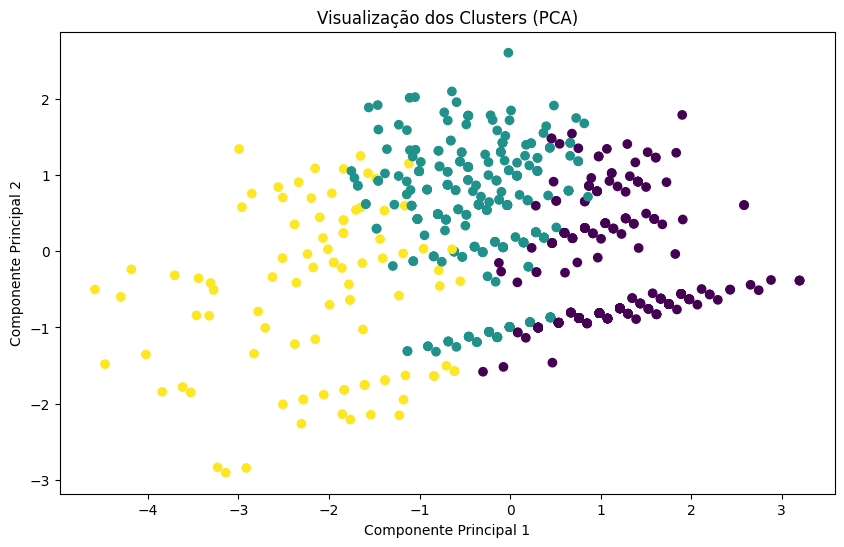

In [134]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans.labels_
)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Visualização dos Clusters (PCA)')

plt.show()